# Inferring behavioral strategies during decision making using GLM-HMMs
One could think of decision-making as a stable process: given the same stimulus, an animal is assumed to respond according to a fixed strategy with some added noise. However, growing evidence suggests that behavior is not stationary. Instead, animals fluctuate between distinct internal states that can persist over many trials. Traditional models, such as the classic lapse model, capture errors as random, independent events, but fail to account for these structured, state-dependent fluctuations in behavior. This raises the question: How can we infer these latent behavioral strategies directly from observed choices?

In this notebook, we address this question using the GLM-HMM framework, which combines a generalized linear model (GLM) with a hidden Markov model (HMM) to capture both how decisions change as a function of stimuli and how strategies evolve over time. We will show how to use choice data to recover hidden behavioral states using the NeMoS implementation of a Bernoulli GLM-HMM, replicating the main findings of Ashwood et al. (2022)<span id="cite1b"></span><a href="#ref1">[PENDING]</a>.

We have four main goals for this tutorial:

1. Explain how to download and preprocess real mice data from the [International Brain Laboratory (IBL) - PENDING]()
2. Show how to create a design matrix with different behavioral predictors
3. Show how to fit choice data using a GLM-HMM
4. Show how to interpret GLM-HMM fitting results
5. Provide some ideas for follow-up analyses


Importantly, throughout the notebook we will assume you already have a solid theoretical understanding of GLMs and GLM-HMMs. If you need an explanation, please refer to our tutorials on GLMs and GLM-HMMs. Moreover, if you already have a good understanding of GLM-HMMs and are interested in different heuristics you could use to overcome difficulties in the fitting process, please refer to our tutorial for fine-grain details of the fitting algorithm and different initialization methods you could use to ensure the best possible fit and thus description of your data under this model.

## GLM-HMMs
GLM-HMMs, also known as input-out HMM (Bengio & Frasconi, 1995) <span id="cite1b"></span><a href="#ref1">[PENDING]</a>, models are useful to analyze how hidden latent states affect observable behavioral (Ashwood et al., 2022) <span id="cite1b"></span><a href="#ref1">[1b]</a> and neural (Escola et al., 2011)<span id="cite1b"></span><a href="#ref1">[PENDING]</a> dynamics. These models are composed by an HMM, governing the distribution over the latent states, and state-specific GLMs, which specify the activity of the system at each state.

<center><img src="images/graphical_model.png" alt="Graphical model of GLM-HMM" width="800" /></center>

In all GLM-HMMs, the HMM component is fully defined by three elements: a state transition matrix, an initial probability vector and an emissions probability distribution (Bishop, 2006)<span id="cite1b"></span><a href="#ref1">[PENDING]</a>. A HMM with K hidden states has a $K \times K$ transition matrix that specifies the probability of transitioning from any state to any other,
\begin{align}
p(z_t=j\mid z_{t-1} = i) = A_{ij}
\end{align}
where $z_{t-1}$ and $z_t$ indicate the latent state at trials $t-1$ and $t$, respectively. The HMM also has a distribution over the initial states, given by a K-element vector $\pi$ whose elements sum to one:
\begin{align}
p(z_1 = i) = \boldsymbol{\pi}_i
\end{align}
Finally, the emissions probability describes the relationship between the state and the observation. In the case of GLM-HMMs, the emissions probability is a GLM (it can be, for example, a Bernoulli GLM); that is, a generalization of linear regression that allows to characterize how an output (behavior, neuronal activity) may vary as a function of an input.

A K-state GLM-HMM contains K independent GLMs, each defined by a weight vector specifying how inputs are integrated in that particular state to give rise to activity. These describe the state-dependent mapping from inputs to activity. So far, we have implemented a GLM with a Bernoulli observation mode i.e., a Bernoulli GLM.
\begin{equation}
y_t \mid \boldsymbol{x}, \boldsymbol{k} \sim Ber(f(-\boldsymbol{x}_t \cdot \boldsymbol{w}_k)) \\
\end{equation}
where $\boldsymbol{w}_k \in \mathbb{R}^M$ denotes the GLM weights for latent state $k \in {1,..,K}$. Thus, the probability of success ($y_t = 1$, which can correspond to a given choice in a binary set up, or a spike count for a time bin; in our case, corresponds to a leftward choice) given the input vector $\boldsymbol{x}_t$ is given by:
\begin{align}
p(y_t=1\mid\boldsymbol{x}_t, z_t = k)  = \frac{1}{1+exp(-\boldsymbol{x}_t \cdot \boldsymbol{w}_k)}
\end{align}
considering a GLM-HMM with a logistic inverse link function.

## 00. Imports

In [41]:
# Imports
import nemos as nmo
from nemos.glm_hmm import GLMHMM
nmo.GLMHMM = GLMHMM # this is the only way I got the GLM HMM module to work when using my own installation...I don't really know why but it won't be a problem when we release anyway
import jax
import jax.numpy as jnp
import numpy as np
import pynapple as nap
import seaborn as sns
from one.api import ONE
from sklearn import preprocessing
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm, LinearSegmentedColormap

from scipy.special import expit
from nemos.glm_hmm.utils import compute_rate_per_state

In [42]:
seed = 65  # Random seed for reproducibility
np.random.seed(seed)
jax.config.update("jax_enable_x64", True)

# Parameters for plotting
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="ticks", palette="colorblind", font_scale=1.5, rc=custom_params)#, context="notebook")

## 01. Downloading the data and understanding the task structure: IBL decision-making task

<center><img src="images/IBL_edited.png" alt="Task schematic" width="500" /></center>

<div style="text-align: center;">

  Task illustration. Modified from IBL et al. (2021) 
   <span id="cite1b"></span><a href="#ref1">[PENDING]</a>.
</div>

We will analyze the IBL decision-making task, which is a variation of the two-alternative forced-choice perceptual detection task (IBL et al., 2021 <span id="cite1b"></span><a href="#ref1">[PENDING]</a>). During this task, a sinusoidal grating with varying contrast [0\%-100\%] appeared either at the right or left side of the screen. The goal for the mice was to indicate this side turning a little wheel so that this turn would accordingly move the stimuli to the center of the screen (Burgess et al. (2021) <span id="cite1b"></span><a href="#ref1">[PENDING]</a>. If the mice chose the side correctly, they would receive a water reward; if not, a noise burst and there would be a 1 second timeout. For the first 90 trials of each session in the task, the stimulus appeared randomly on either side of the screen; after that, the stimulus would appear on one side with fixed probability 0.8 and alternate randomly every 20-100 trials. 

First, let's download the data using [ONE - PENDING]()

In [43]:
# Using ONE's ```load_aggregate``` function, we can retrieve all sessions from a given animal. For this, first we need to instantiate the ```ONE``` object
one = ONE()

# Then we need to choose our subject and run ```load_aggregate```
subject = "CSHL_008"
trials = one.load_aggregate('subjects', subject, '_ibl_subjectTrials.table')

# We can see the information we get by printing the columns
print(trials.columns)

Index(['intervals_0', 'intervals_1', 'goCue_times', 'response_times', 'choice',
       'stimOn_times', 'contrastLeft', 'contrastRight', 'feedback_times',
       'feedbackType', 'rewardVolume', 'probabilityLeft',
       'firstMovement_times', 'goCueTrigger_times', 'stimOnTrigger_times',
       'stimOffTrigger_times', 'stimFreezeTrigger_times', 'stimOff_times',
       'stimFreeze_times', 'phase', 'position', 'quiescence', 'session',
       'task_protocol', 'protocol_number', 'session_start_time'],
      dtype='object')


/Users/camilamaura/coding_projects/glm_hmm_notebook/.venv/lib/python3.12/site-packages/one/util.py:442: ALFWarning: No default revision for dataset aggregates/Subjects/churchlandlab/CSHL_008/_ibl_subjectTrials.table.pqt; using most recent
  warnings.warn(


! Admonition one.search() returns session IDs (eids) that exist as session records in Alyx, while load_aggregate() downloads a pre computed file with trial data pooled across multiple sessions. If you want to get all sessions from a single animal, it is recommended to use ```load_aggregate```, because some sessions may be located in a dataframe without a session identified in itself (but containing multiple sessions with their own session identifiers). 

We are modeling choice as result of observables and behavioral state. Thus, we need choice, stimuli presented and reward obtained. Additionally, we want to keep the session identifier to know when sessions start and end and for plotting. Furthermore, in this task, the probability of the stimulus being in the left or the right side of the screen changes over time within a session. Thus, we also want the information of the probability of the stimulus appearing in a given position.

| Variable            | Description |
|---------------------|-------------|
| choice              | mouse choice: 1 = choice left, -1 = choice right, 0 = violation (no response within the trial period) |
| contrastLeft        | contrast of stimulus presented on the left |
| contrastRight       | contrast of stimulus presented on the right |
| feedbackType        | reward obtained: 1 = success, -1 = failure |
| probabilityLeft     | probability of stimulus being presented on the left of the screen |
| session             | id of session |

Let's extract the meaningful data and see how it looks

In [44]:
trials = trials[["choice", "contrastLeft", "contrastRight", "feedbackType", "probabilityLeft", "session"]]

print(f"choice \nvalues: {trials.choice.unique()}, data type: {trials.choice.dtype}, shape:  \n")
print(f"contrast left \nvalues: {trials.contrastLeft.unique()}, data type: {trials.contrastLeft.dtype} \n")

print(f"contrast right \nvalues: {trials.contrastRight.unique()}, data type: {trials.contrastRight.dtype} \n")

print(f"reward \nvalues: {trials.feedbackType.unique()}, data type: {trials.feedbackType.dtype} \n")

print(f"probability of stimulus on left \nvalues: {trials.probabilityLeft.unique()}, data type: {trials.probabilityLeft.dtype} \n")

print(f"session \n(some) values: {trials.session.unique()[:5]}, data type: {trials.session.dtype}\n")

choice 
values: [ 1 -1  0], data type: int64, shape:  

contrast left 
values: [0.5       nan 1.     0.25   0.125  0.0625 0.    ], data type: float64 

contrast right 
values: [   nan 0.5    1.     0.25   0.125  0.0625 0.    ], data type: float64 

reward 
values: [ 1 -1], data type: int64 

probability of stimulus on left 
values: [0.5 0.8 0.4 0.2 0.1 0.3 0.6 0.7 0.  0.9 1.  0.2], data type: float64 

session 
(some) values: ['e572b45a-34de-453a-b13e-4d90f0374f1e'
 'deee6460-d6e6-4fbf-b7ce-72bc4825d21f'
 'f511e37e-43be-4333-bc1a-2820d1863b30'
 'f6824e3a-54c1-4cf3-a567-a559bf970d19'
 'e3bdbfc1-75e9-4afd-996b-8bed6b8a4a3e'], data type: object



Since we have constructed our model as a Bernoulli with $y_t = 1$ corresponding to rightward choice, we will remap our choices now to match that. 

In [45]:
# Old: right == -1, left == 1, violation == 0
# New: right == 1, left == 0, violati3on == -1
#trials.choice = trials.choice.replace({1: 0, -1: 1, 0: -1})

Now, we will restrict the analysis to the first 90 trials of each session. In this segment, the stimulus appears on the left and right with equal probability (0.5/0.5). In this regime, choices are driven primarily by sensory evidence rather than learned expectations about stimulus probability. After trial 90, the task switches to a block structure in which the left stimulus occurs with probability 0.8 or 0.2, alternating across blocks within the session.

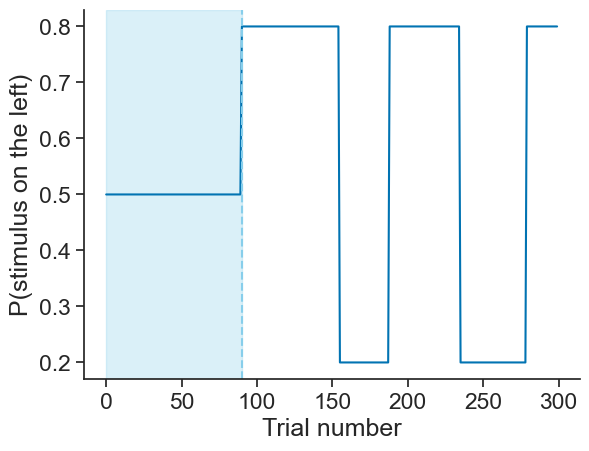

In [46]:
# Choose example session
sess = '726b6915-e7de-4b55-a38e-ff4c461211d3'
# Subset session trials
trials_sess = trials[trials.session == sess].reset_index()

# Plot
plt.plot(trials_sess["probabilityLeft"][:300])
plt.axvspan(0, 90, color="skyblue", alpha=0.3, label="first 90 trials")
plt.axvline(90, color="skyblue", linestyle="--")

plt.ylabel("P(stimulus on the left)")
plt.xlabel("Trial number")
plt.show()

In  Ashwood et al. (2022)<span id="cite1b"></span><a href="#ref1">[PENDING]</a>, only the sessions with less than 10 violations were used. Thus, we will now revise the number of violations, defined as trials where the animal made no choice. i.e choice == 0 during the 50-50 trials. For this:
 1) We must subset sessions which include 50-50 trials and
 2) we must exclude sessions with >10 violation trials [change phrasing: we are following paper]

In [47]:
# Create a list of ids
sessions_ids = trials.session.unique()

# keep only relevant columns for filtering
df_trials = trials[["session", "probabilityLeft", "choice"]]

# Get which sessions contain exactly {0.2, 0.5, 0.8}
valid_prob_sessions = (
    df_trials.groupby("session")["probabilityLeft"]
      .agg(lambda x: set(x.unique()) == {0.2, 0.5, 0.8})
)
# Compute violations only on 50-50 trials
viol_val = 0
violations = (
    df_trials[df_trials["probabilityLeft"] == 0.5]
    .groupby("session")["choice"]
    .apply(lambda x: (x == viol_val).sum())
)
# Apply both restrictions
valid_sessions = violations[
    (violations < 10) & (violations.index.isin(valid_prob_sessions[valid_prob_sessions == True].index))
].index.tolist()

# Make sure they maintain the order of the original dataset (we don't want scrambled trials)
valid_set = set(valid_sessions)
valid_sessions = [
    s for s in trials["session"].drop_duplicates()
    if s in valid_set
]
print(f"# of sessions before restrictions {len(df_trials.session.unique())}")

# Now we can select only the valid sessions for subsequent analyses
df_trials = trials[
    (trials["session"].isin(valid_sessions)) & (df_trials["probabilityLeft"] == 0.5)
]
print(f"# of sessions after restrictions {len(df_trials.session.unique())}")

# of sessions before restrictions 73
# of sessions after restrictions 56


## 02. Building the design matrix
Now, with the valid sessions, we can compute the design matrix. In our case, we are interested in building a design matrix with three predictors: stimuli, previous choice and win stay lose shift.

<center><img src="images/design_matrix_table.png" alt="Task schematic" width="1100" /></center>

Let's go through the process of building the design matrix with one session.

In [48]:
# Select an example session
eid = valid_sessions[0]  
   
# Filter that session
df_sess = df_trials[df_trials["session"] == eid]

# We can select all the necessary values for the design matrix: choice, contrast of stimuli and reward
choice = df_sess['choice'].reset_index(drop=True)
stim_left = df_sess['contrastLeft'].reset_index(drop=True)
stim_right = df_sess['contrastRight'].reset_index(drop=True)
rewarded = df_sess['feedbackType'].reset_index(drop=True)

For the first predictor: signed contrast.

In [49]:
# Create stim vector
stim_left = np.nan_to_num(stim_left, nan=0)
stim_right = np.nan_to_num(stim_right, nan=0)

# now get 1D stim
signed_contrast = stim_left - stim_right
print(signed_contrast)

[ 1.     -1.     -0.25    0.     -0.125  -0.0625 -0.0625  0.25   -0.125
 -0.125   0.25   -0.0625 -0.125  -0.125   0.25    1.      0.     -0.25
  1.     -0.25    0.125  -0.0625 -1.     -0.125  -0.0625  0.125  -0.25
  0.25   -0.0625 -0.0625  0.      0.25    0.125   0.0625 -1.      0.125
  0.125   0.     -0.0625  0.0625 -0.125  -0.25   -1.      0.0625  0.0625
  0.0625  0.25    0.125  -0.125  -0.25   -0.125   0.      0.      0.125
 -0.0625  0.0625  1.      0.0625 -0.125   0.125   0.0625 -0.0625  0.
 -0.0625  1.      0.0625  0.125  -0.25    0.0625  1.      0.0625  0.125
  0.125   0.      0.0625 -1.      0.25   -0.0625  1.      0.      0.
  1.      0.0625 -1.      0.25    0.0625 -0.25    0.25    1.     -0.25  ]


Now we will create the next predictor: previous choice

In [50]:
# Get rid of violation trials i.e trials where the mouse didn't make a choice
# previous choice vector getting rid of violation trials

# violation mask is going to change
valid_choices_idx = np.where(~choice.isin([viol_val]))[0]
valid_choices = choice[valid_choices_idx]
# Shift the array elements one position to the right
previous_choice = np.roll(valid_choices, 1)
# Set first choice as first previous_choice
previous_choice[0] = valid_choices[0]
print(previous_choice)

[ 1  1 -1 -1 -1 -1 -1 -1  1 -1 -1  1  1 -1  1  1  1  1 -1  1 -1  1 -1 -1
 -1 -1  1 -1  1 -1 -1 -1  1  1  1  1  1  1  1 -1  1 -1 -1 -1  1 -1 -1  1
  1  1 -1 -1  1 -1  1 -1  1  1 -1  1  1  1 -1  1 -1  1  1  1 -1  1  1  1
  1  1  1  1 -1  1 -1  1 -1  1  1  1  1  1  1 -1  1  1]


Now we will compute the final predictor: win-stay lose-shift

In [51]:
# choice change of mapping will also change this probably
# remap previous choice vals to {-1, 1} to match 1 -> rightward evidence and -1 -> leftward evidence
remapped_previous_choice = previous_choice
# Keep only rewards corresponding to valid trials
valid_rewards = rewarded[valid_choices_idx]
# Shift the array elements one position to the right
previous_reward = np.roll(valid_rewards, 1)
# Set first choice as first previous_choice
previous_reward[0] = valid_rewards[0]
# wsls: vector of size T, entries are in {-1, 1}.  1 corresponds to previous choice = right and success OR previous choice = left and failure; -1 corresponds to previous choice = left and success OR previous choice = right and failure
wsls = previous_reward * remapped_previous_choice
print(wsls)

[ 1  1 -1 -1 -1 -1 -1 -1  1 -1 -1  1 -1 -1 -1  1  1  1 -1  1 -1  1 -1 -1
 -1 -1  1 -1  1 -1 -1 -1  1  1  1 -1  1  1 -1 -1  1 -1 -1 -1  1  1  1  1
  1 -1 -1 -1 -1  1  1 -1  1  1  1 -1  1  1 -1  1 -1  1  1  1 -1  1  1  1
  1  1  1  1 -1  1 -1  1  1  1  1  1 -1  1  1 -1  1  1]


Now can create our design matrix and fill it with the three vectors: stimuli, previous choice and wsls.

In [52]:
# Remove stimuli of invalid choices
signed_contrast =  signed_contrast[valid_choices_idx]
# Create matrix to be filled with the predictors
n_trials = len(signed_contrast)
# Create empty design matrix of shape (n_trials, n_predictors)
design_mat = np.zeros((n_trials, 3))
# Add signed_contrast in the first predictor in the design matrix
design_mat[:, 0] = signed_contrast
# remap previous choice vals to {-1, 1} to match 1 -> rightward evidence and -1 -> leftward evidence
design_mat[:, 1] = previous_choice #2 * previous_choice - 1
# Add wsls as third predictor in the design matrix
design_mat[:, 2] = wsls

# We then normalize stimuli values across trials.
unnormalized_inpt = design_mat.copy()
normalized_inpt = np.copy(unnormalized_inpt)
normalized_inpt[:, 0] = preprocessing.scale(normalized_inpt[:, 0])

and see our design matrix.

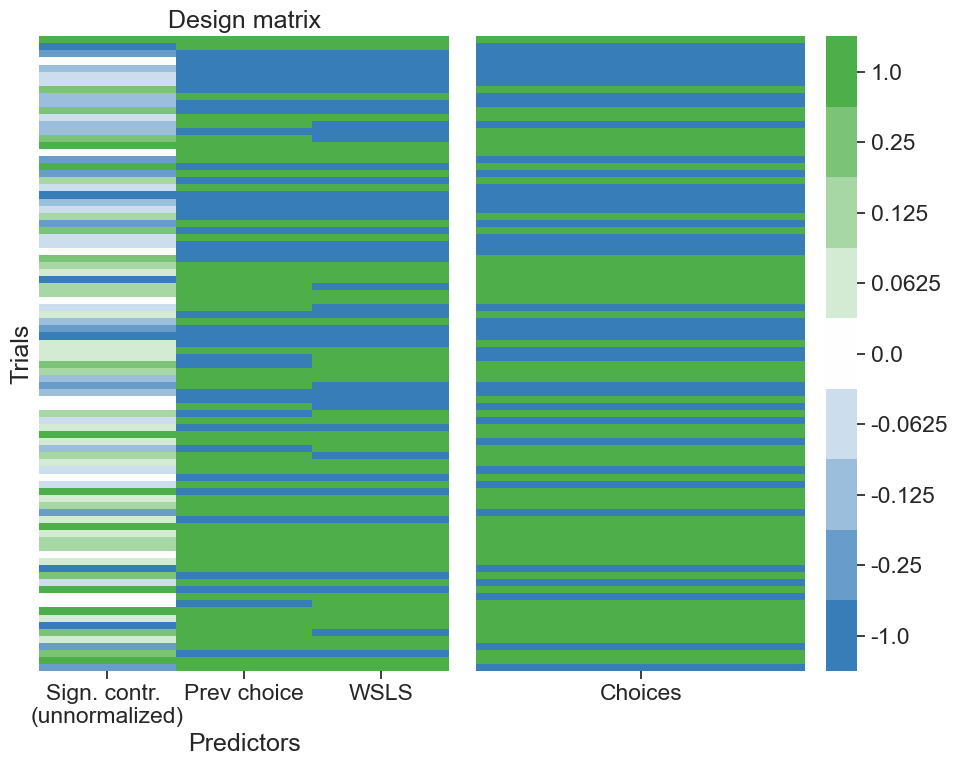

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(10, 8), sharey=True)

# ---- define signed contrast bins ----
signed_levels = np.array([
    -1.0, -0.25, -0.125, -0.0625, 0.0,
     0.0625, 0.125, 0.25, 1.0
])
signed_levels_ticks = signed_levels+.5

all_levels = signed_levels
all_levels = np.unique(all_levels)
all_levels.sort()

cmap_cat = ListedColormap(plt.cm.viridis(np.linspace(0, 1, len(all_levels)+1)))
cmap_cat = LinearSegmentedColormap.from_list(
    "bias_map",
    ["#377eb8", "white", "#4daf4a"]  # left → neutral → right
)
bounds = np.concatenate([
    all_levels - 1e-6,
    [all_levels[-1] + 1]
])

#bounds = all_levels

norm = BoundaryNorm(bounds, cmap_cat.N)

# ---- heatmap 1: full design matrix ----
sns.heatmap(
    unnormalized_inpt,
    ax=axes[0],
    cmap=cmap_cat,
    norm=norm,
    cbar=False
)

axes[0].set_xticks([0.5, 1.5, 2.5],
                   ["Sign. contr. \n(unnormalized)", "Prev choice", "WSLS"])
axes[0].set_yticks([])
axes[0].set_xlabel("Predictors")
axes[0].set_ylabel("Trials")
axes[0].set_title("Design matrix")

# ---- heatmap 2: choices ----
sns.heatmap(
    valid_choices.to_numpy().reshape(-1, 1),
    ax=axes[1],
    cmap=cmap_cat,
    norm=norm,
    cbar=True
)
axes[0].set_yticks([])
axes[1].set_xticks([0.5], ["Choices"])

cbar = axes[1].collections[0].colorbar

midpoints = (bounds[:-1] + bounds[1:]) / 2
cbar.ax.minorticks_off()
cbar.set_ticks(midpoints)
cbar.set_ticklabels([str(v) for v in signed_levels])

plt.tight_layout()
plt.show()


ALTERNATIVE 1 



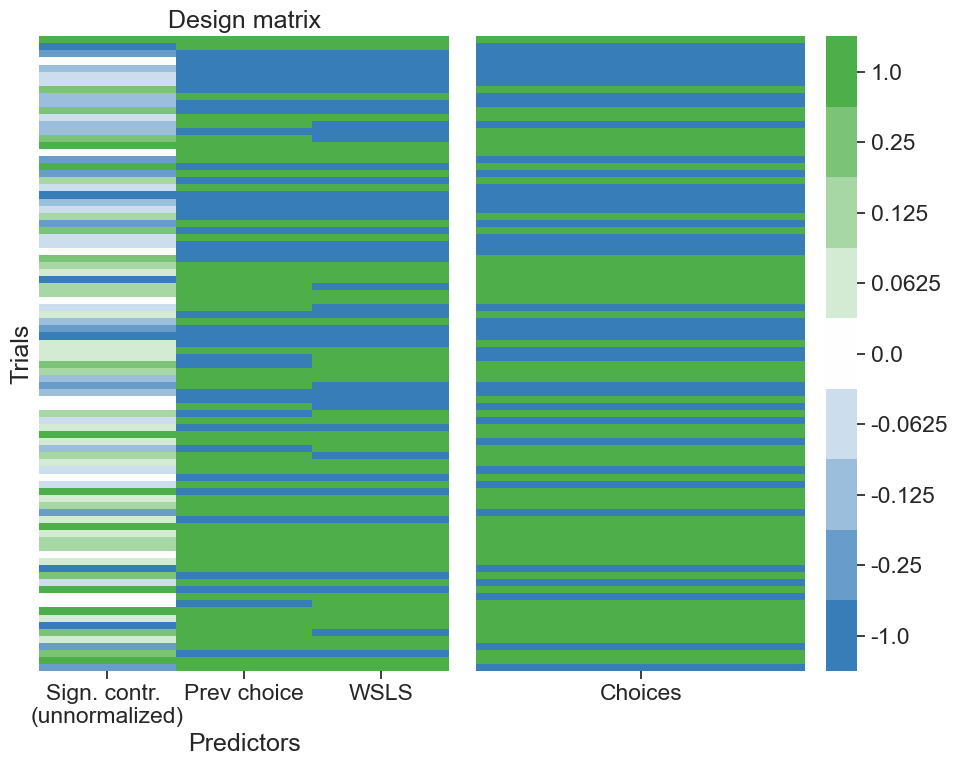

ALTERNATIVE 2 



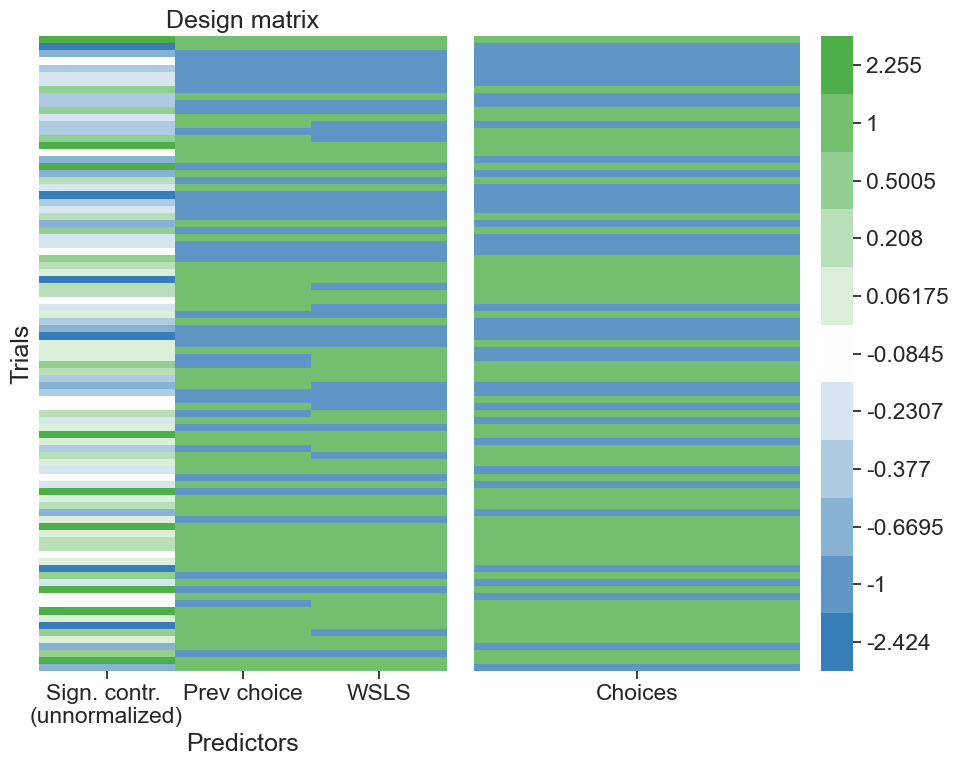

ALTERNATIVE 3 



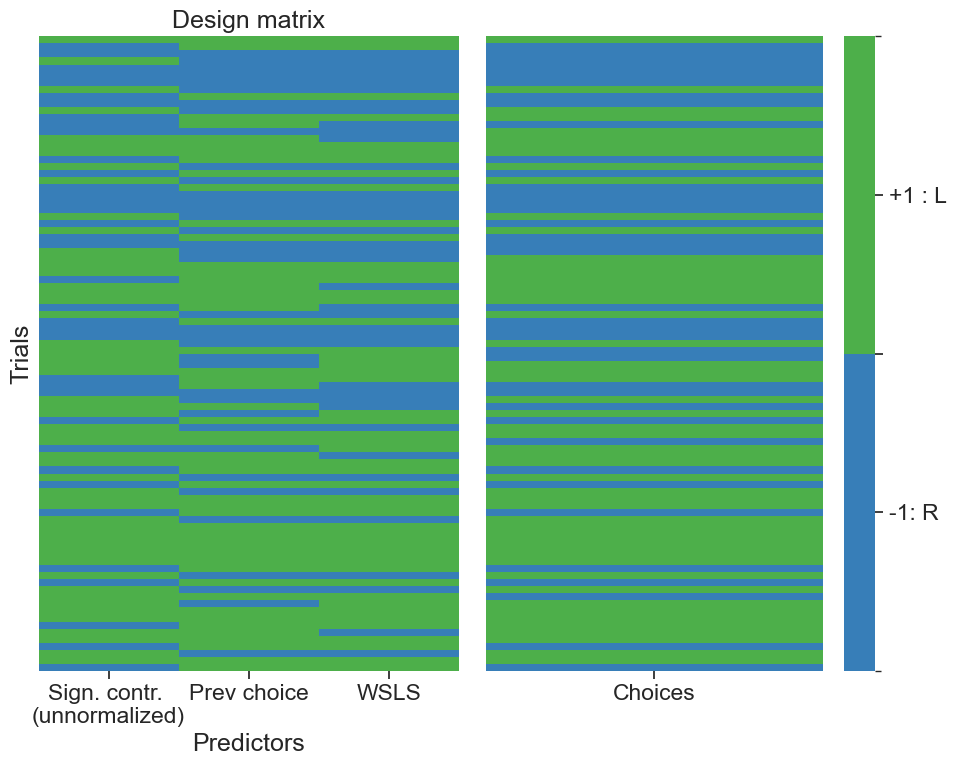

ALTERNATIVE 4 



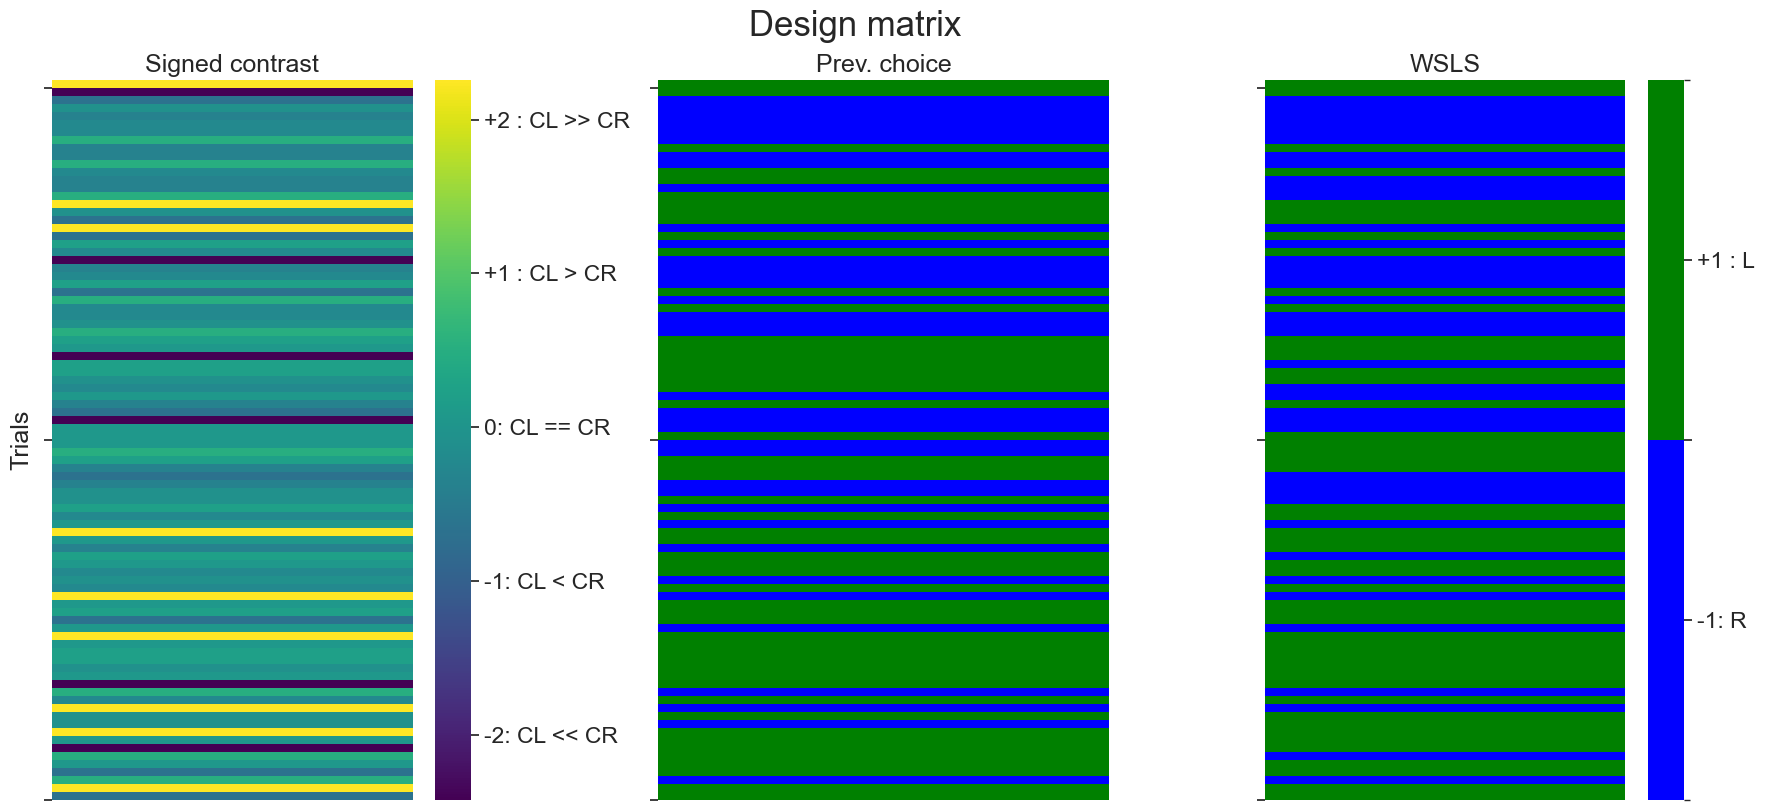

ALTERNATIVE 5 



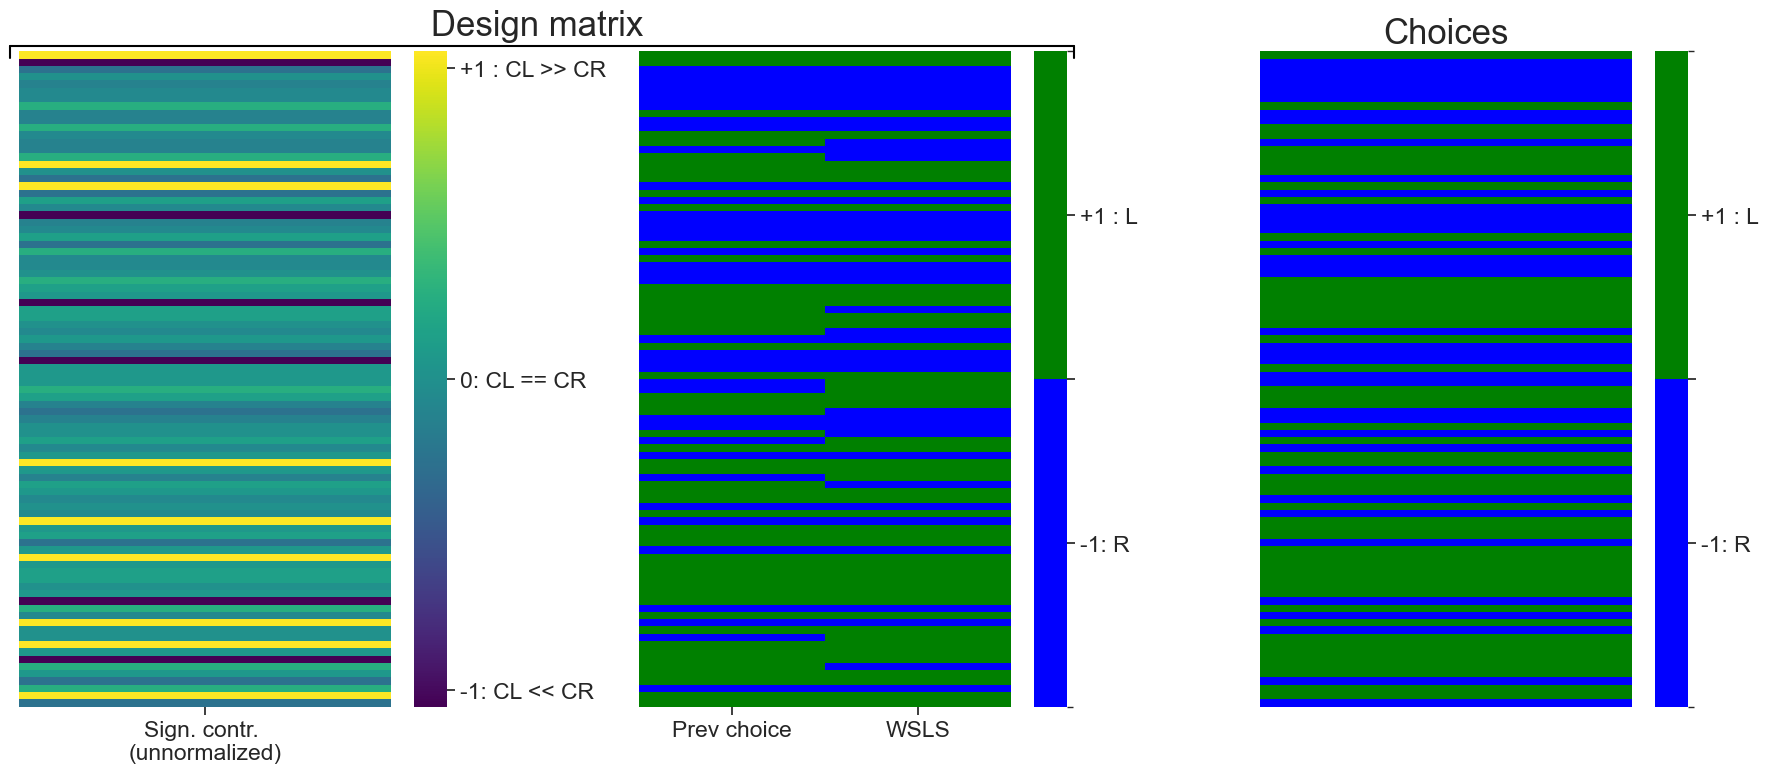

In [54]:

print("ALTERNATIVE 1 \n")
fig, axes = plt.subplots(1, 2, figsize=(10, 8), sharey=True)

# ---- define signed contrast bins ----
signed_levels = np.array([
    -1.0, -0.25, -0.125, -0.0625, 0.0,
     0.0625, 0.125, 0.25, 1.0
])
signed_levels_ticks = signed_levels+.5

all_levels = signed_levels
all_levels = np.unique(all_levels)
all_levels.sort()

cmap_cat = ListedColormap(plt.cm.viridis(np.linspace(0, 1, len(all_levels)+1)))
cmap_cat = LinearSegmentedColormap.from_list(
    "bias_map",
    ["#377eb8", "white", "#4daf4a"]  # left → neutral → right
)
bounds = np.concatenate([
    all_levels - 1e-6,
    [all_levels[-1] + 1]
])

#bounds = all_levels

norm = BoundaryNorm(bounds, cmap_cat.N)

# ---- heatmap 1: full design matrix ----
sns.heatmap(
    unnormalized_inpt,
    ax=axes[0],
    cmap=cmap_cat,
    norm=norm,
    cbar=False
)

axes[0].set_xticks([0.5, 1.5, 2.5],
                   ["Sign. contr. \n(unnormalized)", "Prev choice", "WSLS"])
axes[0].set_yticks([])
axes[0].set_xlabel("Predictors")
axes[0].set_ylabel("Trials")
axes[0].set_title("Design matrix")

# ---- heatmap 2: choices ----
sns.heatmap(
    valid_choices.to_numpy().reshape(-1, 1),
    ax=axes[1],
    cmap=cmap_cat,
    norm=norm,
    cbar=True
)
axes[0].set_yticks([])
axes[1].set_xticks([0.5], ["Choices"])

cbar = axes[1].collections[0].colorbar

midpoints = (bounds[:-1] + bounds[1:]) / 2
cbar.ax.minorticks_off()
cbar.set_ticks(midpoints)
cbar.set_ticklabels([str(v) for v in signed_levels])

plt.tight_layout()
plt.show()

print("ALTERNATIVE 2 \n")
fig, axes = plt.subplots(1, 2, figsize=(10, 8), sharey=True)

# ---- define signed contrast bins (unnormalized) ----
signed_levels = np.array([
    -2.424443102018604,
    -1.0,
    -0.6694842882249763,
    -0.3769911525927051,
    -0.2307445847765695,
    -0.0844980169604339,
     0.06174855085570171,
     0.20799511867183731,
     0.5004882543041086,
     1.0,
     2.255447068097736,
])

all_levels = np.unique(signed_levels)
all_levels.sort()

cmap_cat = LinearSegmentedColormap.from_list(
    "bias_map",
    ["#377eb8", "white", "#4daf4a"]  # left → neutral → right
)

bounds = np.concatenate([
    all_levels - 1e-6,
    [all_levels[-1] + 1]
])

norm = BoundaryNorm(bounds, cmap_cat.N)

# ---- heatmap 1: full design matrix ----
sns.heatmap(
    normalized_inpt,
    ax=axes[0],
    cmap=cmap_cat,
    norm=norm,
    cbar=False
)

axes[0].set_xticks([0.5, 1.5, 2.5],
                   ["Sign. contr. \n(unnormalized)", "Prev choice", "WSLS"])
axes[0].set_yticks([])
axes[0].set_xlabel("Predictors")
axes[0].set_ylabel("Trials")
axes[0].set_title("Design matrix")

# ---- heatmap 2: choices ----
sns.heatmap(
    valid_choices.to_numpy().reshape(-1, 1),
    ax=axes[1],
    cmap=cmap_cat,
    norm=norm,
    cbar=True
)
axes[0].set_yticks([])
axes[1].set_xticks([0.5], ["Choices"])

cbar = axes[1].collections[0].colorbar

midpoints = (bounds[:-1] + bounds[1:]) / 2
cbar.ax.minorticks_off()
cbar.set_ticks(midpoints)
cbar.set_ticklabels([f"{v:.4g}" for v in signed_levels])

plt.tight_layout()
plt.show()
print("ALTERNATIVE 3 \n")
fig, axes = plt.subplots(1, 2, figsize=(10
                                        , 8), sharey=True)
cmap_cat = ListedColormap(["#377eb8",  "#4daf4a"])
bounds = [-1,0,1]
norm = BoundaryNorm(bounds, cmap_cat.N)

sns.heatmap(
    unnormalized_inpt,
    ax=axes[0],
    cmap=cmap_cat,
    norm=norm,
    cbar=False,
)

# choices panel (also binary)
sns.heatmap(
    valid_choices.to_numpy().reshape(-1, 1),
    ax=axes[1],
    cmap=cmap_cat,
    norm=norm,
    cbar=True,
    #cbar_kws={"label": "Value"}#, "ticks": [-1, 1]},

)
axes[1].set_xlabel("")
axes[1].set_xticks([.5], ["Choices"])

c_bar = axes[1].collections[0].colorbar
c_bar.set_ticks([-.5, 0, .5])
c_bar.set_ticklabels(['-1: R', '', '+1 : L'])

axes[0].set_xticks([0.5,1.5,2.5], ["Sign. contr. \n(unnormalized)", "Prev choice", "WSLS"])
axes[0].set_yticks([])
axes[0].set_xlabel("Predictors")
axes[0].set_ylabel("Trials")
axes[0].set_title("Design matrix")

plt.tight_layout()
plt.show()

print("ALTERNATIVE 4 \n")

fig, axes = plt.subplots(1, 3, figsize=(18
                                        , 8), sharey=True)


cols = ["Signed contrast", "Prev. choice", "WSLS"]

# continuous normalization for col 0
norm_cont = None  # let seaborn handle automatically

# discrete normalization for cols 1 and 2
cmap_bin = ListedColormap(["blue", "green"])
norm_bin = BoundaryNorm([-2, 0,2], cmap_bin.N)

for i, col in enumerate(cols):

    is_continuous = (i == 0)

    sns.heatmap(
        normalized_inpt[:, [i]],
        ax=axes[i],
        cmap="viridis" if is_continuous else cmap_bin,
        norm=norm_cont if is_continuous else norm_bin,
        cbar=((i == 0) or (i==2)),
       
    )

    axes[i].set_title(col)
    axes[i].set_xticks([])
    axes[i].set_yticks([1, 45, 90])
    axes[i].set_yticklabels([1, 45, 90] if i == 0 else [])

# choices panel (also binary)
'''
sns.heatmap(
    valid_choices.to_numpy().reshape(-1, 1),
    ax=axes[3],
    cmap=cmap_bin,
    norm=norm_bin,
    cbar=True,
    cbar_kws={"label": "Value"}#, "ticks": [-1, 1]},

)

axes[3].set_title("Choices")
axes[3].set_xticks([])
axes[3].set_yticks([])
'''
c_bar = axes[2].collections[0].colorbar
c_bar.set_ticks([-1, 0, 1])
c_bar.set_ticklabels(['-1: R', '', '+1 : L'])

c_bar = axes[0].collections[0].colorbar
c_bar.set_ticks([-2, -1, 0, 1, 2])
c_bar.set_ticklabels(
    ['-2: CL << CR ',
     '-1: CL < CR', 
     '0: CL == CR',
     '+1 : CL > CR',
     '+2 : CL >> CR',

])


pos0 = axes[0].get_position()
pos1 = axes[2].get_position()

x_mid = ((pos0.x0 + pos1.x1) / 2) -.005
y_top = max(pos0.y1, pos1.y1) + .1


fig.text(x_mid, y_top, "Design matrix", ha="center", va="bottom", fontsize=25)
axes[0].set_ylabel("Trials")


plt.tight_layout()
plt.show()

print("ALTERNATIVE 5 \n")

fig, axes = plt.subplots(1, 3, figsize=(18
                                        , 8), sharey=True)

cols = ["Sign. contr. (z-scored)", "Prev. choice", "WSLS"]

# continuous normalization for col 0
norm_cont = None  # let seaborn handle automatically

# discrete normalization for cols 1 and 2
cmap_bin = ListedColormap(["blue", "green"])
norm_bin = BoundaryNorm([-2, 0,2], cmap_bin.N)

is_continuous = True
sns.heatmap(
    unnormalized_inpt[:, [0]],
    ax=axes[0],
    cmap="viridis" if is_continuous else cmap_bin,
    norm=norm_cont if is_continuous else norm_bin,
    cbar=True,
    #cbar_kws={"label": "Value"}
)
axes[0].set_xticks([.5], ["Sign. contr. \n(unnormalized)"])

axes[0].set_yticks([1, 45, 90])
axes[0].set_yticklabels([1, 45, 90])

c_bar = axes[0].collections[0].colorbar
c_bar.set_ticks([-.95, 0, .95])
c_bar.set_ticklabels(
    ['-1: CL << CR ',
     '0: CL == CR',
     '+1 : CL >> CR',

])

is_continuous = False
sns.heatmap(
    normalized_inpt[:, 1:3],
    ax=axes[1],
    cmap="viridis" if is_continuous else cmap_bin,
    norm=norm_cont if is_continuous else norm_bin,
    cbar=True,
    #cbar_kws={"label": "Value"}
)

axes[1].set_xticks([.5,1.5], ["Prev choice", "WSLS"])
c_bar = axes[1].collections[0].colorbar
c_bar.set_ticks([-1, 0, 1])
c_bar.set_ticklabels(['-1: R', '', '+1 : L'])


# choices panel (also binary)
sns.heatmap(
    valid_choices.to_numpy().reshape(-1, 1),
    ax=axes[2],
    cmap=cmap_bin,
    norm=norm_bin,
    cbar=True,
    #cbar_kws={"label": "Value"}#, "ticks": [-1, 1]},

)
axes[2].set_title("Choices", fontsize=25)

axes[2].set_xticks([])
axes[2].set_yticks([])

c_bar = axes[2].collections[0].colorbar
c_bar.set_ticks([-1, 0, 1])
c_bar.set_ticklabels(['-1: R', '', '+1 : L'])

# --- title of design matrix
pos0 = axes[0].get_position()
pos1 = axes[1].get_position()

x_mid = ((pos0.x0 + pos1.x1) / 2)-.05
y_top = max(pos0.y1, pos1.y1) + .055


fig.text(x_mid, y_top, "Design matrix", ha="center", va="bottom", fontsize=25)


x_left = pos0.x0 - .115

x_right = pos1.x1 + .02
y = max(pos0.y1, pos1.y1) + 0.05
h = 0.015  # bracket height

# top horizontal line
fig.lines.append(plt.Line2D([x_left, x_right], [y, y],
                            transform=fig.transFigure, color="black"))

# left vertical tick
fig.lines.append(plt.Line2D([x_left, x_left], [y, y - h],
                            transform=fig.transFigure, color="black"))

# right vertical tick
fig.lines.append(plt.Line2D([x_right, x_right], [y, y - h],
                            transform=fig.transFigure, color="black"))


plt.tight_layout()
plt.show()

We will carry out the exact same process but for all trials. Our design matrix each row will be a trial, so effectively this means that we will carry out the same process up until the normalization and then normalize.

In [55]:
def get_data_this_session(eid, df_trials):
    df_sess = df_trials[df_trials["session"] == eid]
    stim_left = df_sess['contrastLeft'].reset_index(drop=True)
    stim_right = df_sess['contrastRight'].reset_index(drop=True)
    rewarded = df_sess['feedbackType'].reset_index(drop=True)
    choice = df_sess['choice'].reset_index(drop=True)
    return choice, stim_left, stim_right, rewarded

def get_valid_choice(choice, viol_val):
    # takes in remapped choices
    # Get rid of violation trials i.e trials where the mouse didn't make a choice
    # previous choice vector getting rid of violation trials
    valid_choices_idx = np.where(~choice.isin([viol_val]))[0]
    valid_choices = choice[valid_choices_idx]
    return valid_choices, valid_choices_idx
    

def create_previous_choice_vector(valid_choices):
    # takes in already remapped valid choices and .
    
    # Shift the array elements one position to the right
    previous_choice = np.roll(valid_choices, 1)
    # Set first choice as first previous_choice
    previous_choice[0] = valid_choices[0]
    return previous_choice
        
def create_stim_vector(stim_left, stim_right):
    # Create stim vector
    stim_left = np.nan_to_num(stim_left, nan=0)
    stim_right = np.nan_to_num(stim_right, nan=0)
    # now get 1D stim
    #signed_contrast = stim_right - stim_left
    signed_contrast = stim_left - stim_right
    return signed_contrast

def create_wsls_covariate(previous_choice, rewarded, valid_choices_idx):
    '''
    inputs:
    previous_choice: vector of size T, entries are in {0, 1} and 0
    corresponds to left choice, 1 corresponds to right choice
    
    rewarded: vector of size T, entries are in {-1, 1} and -1 corresponds to
    failure, 1 corresponds to success
    valid_choices_idx : idx of valid trials
    
    wsls: vector of size T, entries are in {-1, 1}.  1 corresponds to
    previous choice = right and success OR previous choice = left and
    failure; -1 corresponds to previous choice = left and success OR previous choice = right and failure
    '''
    # remap previous choice vals to {-1, 1}
    remapped_previous_choice = previous_choice #2 * previous_choice - 1
    # Keep only rewards corresponding to valid trials
    valid_rewards = rewarded[valid_choices_idx]

    # Shift the array elements one position to the right
    previous_reward = np.roll(valid_rewards, 1)
    # Set first choice as first previous_choice
    previous_reward[0] = valid_rewards[0]
    # wsls: vector of size T, entries are in {-1, 1}.  1 corresponds to previous choice = right and success OR previous choice = left and failure; -1 corresponds to previous choice = left and success OR previous choice = right and failure
    wsls = previous_reward * remapped_previous_choice
    assert len(np.unique(wsls)) == 2, "wsls should be in {-1, 1}"
    return wsls

def remap_choice_vals(choice):
    # raw choice vector has CW = 1 (correct response for stim on left),
    # CCW = -1 (correct response for stim on right) and viol = 0.  Let's
    # remap so that CW = 0, CCw = 1, and viol = -1
    new_choice = choice.replace({1: 0, -1: 1, 0: -1})
    return new_choice

def create_design_matrix(choice, stim_left, stim_right, rewarded, viol_val):
    # Stimuli predictor before filtering for valid trials
    signed_contrast = create_stim_vector(stim_left, stim_right)

    # make choice vector so that correct response for stim>0 is choice =1
    # and is 0 for stim <0 (viol is mapped to -1)
    #choice = remap_choice_vals(choice)
    valid_choices, valid_choices_idx = get_valid_choice(choice, viol_val)
    previous_choice = create_previous_choice_vector(valid_choices)

    # create wsls vector:
    wsls = create_wsls_covariate(previous_choice, rewarded, valid_choices_idx)
    
    # filter for valid trials
    signed_contrast =  signed_contrast[valid_choices_idx]
    
    n_trials = len(signed_contrast)
    design_mat = np.zeros((n_trials, 3))
    design_mat[:, 0] = signed_contrast    

    # map previous choice to {-1,1}
    design_mat[:, 1] = 2 * previous_choice - 1
    design_mat[:, 2] = wsls
    return design_mat

def get_all_unnormalized_data_this_session(eid, df_trials, viol_val):
    choice, stim_left, stim_right, rewarded = get_data_this_session(eid, df_trials)
    unnormalized_design_matrix = create_design_matrix(choice, stim_left, stim_right, rewarded, viol_val)
    #y = np.expand_dims(remap_choice_vals(choice), axis=1)
    valid_choices, _ = get_valid_choice(choice, viol_val)
    # remap choices to 1 and 0 to match bernoulli trials
    valid_choices = valid_choices.replace({1: 1, -1: 0})
    y = np.expand_dims(valid_choices, axis=1)
    session = [eid for i in range(y.shape[0])]
    rewarded = np.expand_dims(rewarded, axis=1)
    return unnormalized_design_matrix, y, session, rewarded

def get_unnormalized_design_mat(valid_sessions, df_trials, viol_val):
    sess_counter = 0
    for eid in valid_sessions:
        unnormalized_inpt, y, session, rewarded = \
            get_all_unnormalized_data_this_session(
                eid, df_trials, viol_val)
        if sess_counter == 0:
            animal_unnormalized_inpt = np.copy(unnormalized_inpt)
            animal_y = np.copy(y)
            animal_session = session
            animal_rewarded = np.copy(rewarded)
        else:
            animal_unnormalized_inpt = np.vstack(
                (animal_unnormalized_inpt, unnormalized_inpt))
            animal_y = np.vstack((animal_y, y))
            animal_session = np.concatenate((animal_session, session))
            animal_rewarded = np.vstack((animal_rewarded, rewarded))
        sess_counter += 1
    # Normalize
    animal_normalized_inpt = np.copy(animal_unnormalized_inpt)
    animal_normalized_inpt[:, 0] = preprocessing.scale(animal_unnormalized_inpt[:, 0])
    
    return animal_unnormalized_inpt, animal_normalized_inpt, animal_y.flatten(), animal_session

In [56]:
unnormalized_inpt, design_matrix, choices_mouse, session = get_unnormalized_design_mat(valid_sessions, df_trials, viol_val)

Importantly, do not do 3000 trials at once! Instead, they generally do several sessions of 100-300 trials, and we use all the sessions together to fit our model. For our model to be accurate, we need to tell it when our session boundaries are: we don't want it to compute all sessions as if they were one. 

With NeMoS, we have two ways of indicating the beginning of a new session. When using a design matrix and a choice vector that are Numpy objects, NeMoS treats NaNs either in the input matrix X or in the choice vector y as indicators of new sessions. You can also use a Pynapple Tsd or TsdFrame to demarcate sessions, which is what we will use now.

admonition !! careful, if your choice data contains nan values, they will be handled as new sessions, so make sure to address this promptly.

In [57]:
# new_sess array
# Create array of 1s and 0s marking session boundaries
new_sess_mouse = np.zeros(len(session), dtype=int)
new_sess_mouse[0] = 1  # First entry is always 1

# Mark where session changes
new_sess_mouse[1:] = (session[1:] != session[:-1]).astype(int)

# Get positions of start of sessions
new_sess_pos = np.array(np.where(new_sess_mouse==1))
# Get length of session
sess_length = np.array(np.where(new_sess_mouse==1))[0][1] - 1 # substracting the starting trial

We will use a ```nap.Tsd``` now, because the choices are a 1-dimensional time series. To initialize it, we need the length of the series ```t``` and the data of the time series ```d``` (our choices vector). In addition to this, we can we can initialize our ```nap.Tsd``` with a ```time_support``` property, and this way store both the choices and the sessions information in the same object.

admonition When dealing with 2-dimensional time series, you should use the ```nap.TsdFrame``` object. If you want to learn more about Pynapple objects, check out [Pynapple documentation](https://pynapple.org/user_guide/01_introduction_to_pynapple.html).

In [58]:
choices_tsd = nap.Tsd(t = np.arange(choices_mouse.shape[0]), d=choices_mouse, time_support=nap.IntervalSet(start=new_sess_pos, end = new_sess_pos+ sess_length))

print(f"choices tsd \n {choices_tsd} \n")
print(f"time support\n {choices_tsd.time_support}")

choices tsd 
 Time (s)
----------  --
0.0          1
1.0          0
2.0          0
3.0          0
4.0          0
5.0          0
6.0          0
...
5033.0       0
5034.0       0
5035.0       0
5036.0       0
5037.0       0
5038.0       0
5039.0       0
dtype: int64, shape: (5040,) 

time support
 index    start    end
0        0.0      89.0
1        90.0     179.0
2        180.0    269.0
3        270.0    359.0
4        360.0    449.0
5        450.0    539.0
6        540.0    629.0
...      ...      ...
49       4410.0   4499.0
50       4500.0   4589.0
51       4590.0   4679.0
52       4680.0   4769.0
53       4770.0   4859.0
54       4860.0   4949.0
55       4950.0   5039.0
shape: (56, 2), time unit: sec.


## 03. Fitting a GLM-HMM with NeMoS (Maximum Likelihood)
As mentioned above, we will use a Bernoulli GLM to model this mouse's choices. For this, we first need to initialize the ```GLMHMM``` object. The only mandatory thing to have to declare is the number of states. In Ashwood et al. (2022) <span id="cite1b"></span><a href="#ref1">[PENDING]</a>, they found that most mice used 3 decision-making states when performing the task. Thus, in our case, we will initialize the ```GLMHMM``` object with 3 states. 

! admonition The default observation model for the GLM-HMM is this model is Bernoulli, but we also have Categorical (Multinomial), Poisson, Gamma, Negative Binomial and Gaussian available. Moreover, if desired, you can also set a different observation model of your choice. You can also personalize the inverse link function. Convexity non guaranteed for all likelihood functions, refer to Escola et al (2011)<span id="cite1b"></span><a href="#ref1">[PENDING]</a> and also to [the other notebook - PENDING]()

DONT EDIT, MIGHT CHANGE :)
If required, you can further personalize the ```GLMHMM``` object settings. Beyond the number of states, the observation model and the inverse link function, you can also initialization functions for to aid parameter estimation. 

If you don't set up any initialization settings, you would use the NeMoS defaults:
- ``"glm_params_init"``: ``"random"`` - small random coefficients, mean-rate intercept
- ``"scale_init"``: ``"constant"`` - scale initialized to 1.0
- ``"initial_proba_init"``: ``"uniform"`` - equal probability for all states
- ``"transition_proba_init"``: ``"sticky"`` - high self-transition probability (0.95)

Right now we will use NeMoS defaults.

! admonition importance of choice of initial parameters in the context of GLM HMMs, link to other notebook

- Add k means init as another option

In [59]:
n_states = 3

model = nmo.glm_hmm.GLMHMM(
    n_states,
    regularizer = "Ridge")

print(model)

GLMHMM(
    n_states=3,
    observation_model=BernoulliObservations(),
    inverse_link_function=logistic,
    regularizer=Ridge(),
    regularizer_strength=1.0,
    solver_name='GradientDescent[optimistix]',
    initialization_funcs={'glm_params_init': <function random_glm_params_init at 0x12f1c5300>, 'scale_init': <function constant_scale_init at 0x12f1c4b80>, 'transition_proba_init': <function sticky_transition_proba_init at 0x12f1c45e0>, 'initial_proba_init': <function uniform_initial_proba_init at 0x12f1c5760>},
    initialization_kwargs={'glm_params_init': {}, 'scale_init': {}, 'transition_proba_init': {}, 'initial_proba_init': {}},
    maxiter=1000,
    tol=1e-08
)


add admonition on regularization

Once we created our object, we can fit our model. The fit function takes two mandatory arguments: the design matrix we created in the previous step and the ```choices_tsd```.

! admonition on how to choose a good initialization of parameters
Probably point them to the other notebook

In [60]:
# indices where a new session starts
new_sess_idx = np.where(new_sess_mouse == 1)[0][1:] # skip first

# insert NaNs before each new session start
choices_with_nan = np.insert(choices_mouse.astype(float), new_sess_idx, np.nan)

# insert rows of NaNs at session boundaries
design_mat_with_nan = np.insert(design_matrix, new_sess_idx, np.nan, axis=0)

# NaNs in choices
#model.fit(design_matrix, choices_with_nan)
# Error: X and y must have the same number of samples

# try both with nans
#model.fit(design_mat_with_nan, choices_with_nan)
# Error: GLM-HMM requires continuous time-series data. NaN values must only appear at the beginning or end of the data, not in the middle.

In [61]:
model.fit(design_matrix, choices_tsd)

,n_states,3
,observation_model,BernoulliObservations()
,inverse_link_function,<function log...t 0x12edd2700>
,regularizer,Ridge()
,regularizer_strength,1.0
,dirichlet_prior_alphas_init_prob,None
,dirichlet_prior_alphas_transition,None
,solver_name,'GradientDescent[optimistix]'
,solver_kwargs,{}
,initialization_funcs,"{'glm_params_init': <function ran...t 0x12f1c5300>, 'initial_proba_init': <function uni...t 0x12f1c5760>, 'scale_init': <function con...t 0x12f1c4b80>, 'transition_proba_init': <function sti...t 0x12f1c45e0>}"
,initialization_kwargs,"{'glm_params_init': {}, 'initial_proba_init': {}, 'scale_init': {}, 'transition_proba_init': {}}"


In [62]:
permutation = jnp.array([1, 2, 0])
model.coef_ = model.coef_[:, permutation]
model.intercept_ = model.intercept_[permutation]
model.transition_prob_ = model.transition_prob_[permutation][:, permutation]

If we want to see our glm-hmm parameters, we can call ```model.coef_```. This will output the coefficients of the glm per state, with shape (n_features, n_states)

In [63]:
print(f"shape \n {model.coef_.shape} \n")
print(f"coefficients \n {model.coef_}")

shape 
 (3, 3) 

coefficients 
 [[ 6.08730466  1.54097663  1.57562039]
 [ 0.07301574 -0.15384796  0.23446394]
 [ 0.08765514  0.28756203  0.28354841]]


Similarly, to see the intercept, we can call ```model.intercept_```, which will output the intercept per state. The shape of this object is (n_states)

In [64]:
print(f"shape \n {model.intercept_.shape} \n")
print(f"intercept \n {model.intercept_}")

shape 
 (3,) 

intercept 
 [ 0.09674681  2.58108133 -1.90403002]


and thats all it takes!

## 04. Interpreting the fitting results

### 04.1 Interpreting the GLM weights
First, we can plot the GLM weights obtained for our 3-state model. We can see that the coefficients on state 1 have a large weight on the stimulus and low weight on the other predictors. Conversely, in states 2 and 3, the stimulus coefficient is low. State 2 has a large positive weight on bias, while State 3 has a large negative weight on bias. Since the sign of our predictors indicates the side of evidence and their magnitude indicates the strength of such evidence, State 2 coefficients suggest a large bias on to a rightward choice, while State 2 coefficients suggest a large bias to a leftward choice. All states have similarly low coefficients for prev. choice and wsls, with State 1 showing the smallest of them. 

As a reminder, the task consisted on indicating whether the stimulus was located at the right or the left of the screen using the stimulus contrast information. Thus, the optimal strategy is to maximally use stimulus contrast to guide decision making, and not rely on bias, previous choice or wsls.

In [65]:
def plot_glm_weights(model):
    plt.figure(figsize=(6, 5))
    colors = ["#ff7f00",  "#4daf4a","#377eb8"]

    n_features = model.coef_.shape[0]+1 # add 1 for the intercept
    n_states = model.coef_.shape[1]
    
    # Change order of weights so output matches Ashwood et al. (2022) 2e plot
    recovered_weights = np.zeros((n_features,n_states)) 
    recovered_weights[0,:] = model.coef_[0,:] # stimulus
    recovered_weights[1,:] = model.intercept_ # bias
    recovered_weights[2:,:] = model.coef_[1:,:] # prev choice, wsls
    
    # Labels for plot matching Ashwood et al. (2022) 2e plot
    X_labels = ["Stimulus", "Bias", "Prev.choice", "WSLS"]

    for state in range(n_states):
        plt.plot(
            range(n_features),
            recovered_weights[:, state],
            color=colors[state],
            marker="o",
            lw=1.5,
            label="State {}".format(state + 1),
            linestyle="-",
        )
            
    plt.yticks([-2.5, 0, 2.5, 5])
    plt.ylabel("GLM weight")
    plt.xlabel("Covariate")
    plt.xticks([i for i in range(n_features)], X_labels, fontsize=12, rotation=45)
    plt.axhline(y=0, color="k", alpha=0.5, ls="--")
    plt.legend()
    plt.tight_layout()
    plt.show()
    return None

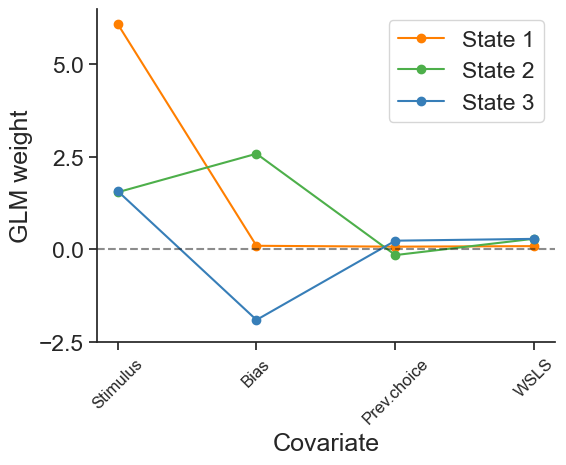

In [66]:
plot_glm_weights(model)

### 04.2 Interpreting the transition matrix
Mention usually is good to have sticky matrices. 

Ashwood: The transition matrix for the fitted three-state model describes the transition probabilities among three different states, each of which corresponds to a different decision-making strategy (Fig. 2d). Large entries along the diagonal of this matrix, ranging between 0.94 and 0.98, indicate a high probability of remaining in the same state for multiple trials.

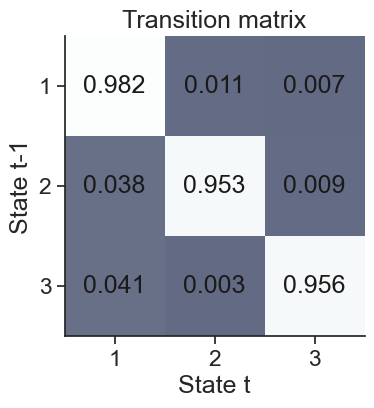

In [67]:
n_decimals = 3

fig = plt.figure(figsize=(8, 3))
plt.imshow(model.transition_prob_, vmin=-0.8, vmax=1, cmap='bone')

for i in range(model.transition_prob_.shape[0]):
    for j in range(model.transition_prob_.shape[1]):
        text = plt.text(j, i, str(np.around(model.transition_prob_[i, j], decimals=n_decimals))[:n_decimals+2], ha="center", va="center",
                        color="k")
plt.xlim(-0.5, n_states - 0.5)
plt.xticks(range(0, n_states), ('1', '2', '3'))
plt.yticks(range(0, n_states), ('1', '2', '3'))
plt.ylim(n_states - 0.5, -0.5)
plt.ylabel("State t-1",)
plt.xlabel("State t")
plt.title("Transition matrix")

plt.subplots_adjust(0, 0, 1, 1)

### 04.3 Interpreting how different GLM weight combinations produce different behaviors: building a psychometric curve using ```compute_rate_per_state```
To understand how different states "affect" (change wording) choice behavior, we can use a psychometric curve.

Ashwood: 
We can visualize the decision-making strategies associated with these states by plotting the corresponding psychometric curves. (Fig. 2g), which show the probability of a rightward choice as a function of the stimulus, conditioned on both previous choice and reward. The steep curve observed in state 1, which corresponds to the mouse achieving near-perfect performance on high-contrast stimuli, led us to adopt the name ‘engaged’ to describe this state. By comparison, the psychometric curves for states 2 and 3 reflected large leftward and rightward biases, respectively. They also had relatively large dependence on previous choice and reward, as indicated by the gap between solid and dashed lines.

Using the fit GLM-HMM parameters for this animal and the true sequence of stimuli presented to the mouse, we generated a time series with the same number of trials as those that the example mouse had in its dataset. At each trial, regardless of the true stimulus presented, we calculated pt(“R”) for each of the nine possible stimuli by averaging the per-state psychometric curves of g and weighting by the appropriate row in the transition matrix (depending on the sampled latent state at the previous trial). Finally, we averaged the per-trial psychometric curves across all trials to obtain the curve that is shown in black, whereas the empirical choice data of the mouse are shown in red, as are 95% confidence intervals (n between 530 and 601, depending on stimulus value). acc., accuracy.

In [68]:
class PARAMS:
    def __init__(self, coef, intercept):
        self.coef = coef
        self.intercept = intercept
param = PARAMS(model.coef_, model.intercept_)
#compute_rate_per_state(design_matrix, model, model.inverse_link_function)
rate_per_stat = compute_rate_per_state(design_matrix, param, model.inverse_link_function)

# Error : 'GLMHMM' object has no attribute 'coef' || should be coef_?


In [69]:
#rate_per_stat = compute_rate_per_state(design_matrix, model, model.inverse_link_function)

In [70]:
[max(stim_vals), 0, min(stim_vals)]

NameError: name 'stim_vals' is not defined

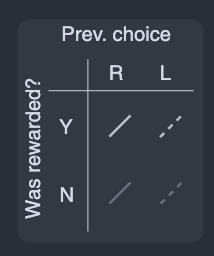

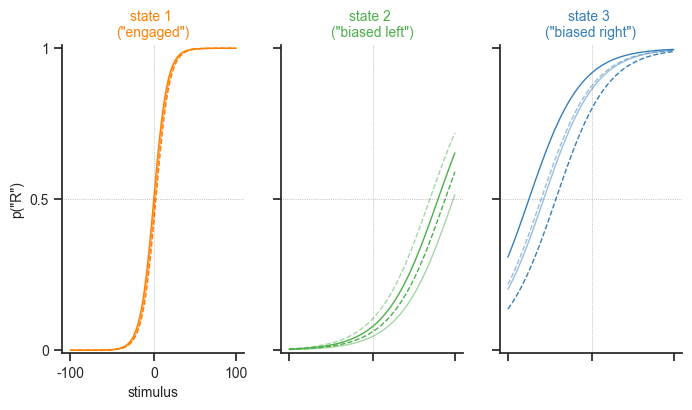

In [ ]:
class PARAMS:
    def __init__(self, coef, intercept):
        self.coef = coef
        self.intercept = intercept
param = PARAMS(model.coef_, model.intercept_)

def get_prob_left(model, inpt, k, pc, wsls):
    # pending to make this more elegant with NeMoS
    # stim vector
    min_val_stim = np.min(inpt[:, 0])
    max_val_stim = np.max(inpt[:, 0])
    
    stim_vals = np.arange(max_val_stim, min_val_stim, -0.05)
    
    # create input matrix - cols are stim, pc, wsls, bias
    x = np.array([
        stim_vals,
        np.repeat(pc, len(stim_vals)),
        np.repeat(wsls, len(stim_vals)),
    ]).T        
    
    return stim_vals, compute_rate_per_state(x, param, model.inverse_link_function)[:,k] 

#stim_vals, prob_left_max  = get_prob_left(model, design_matrix, 0, 1, 1)
#_, prob_left_min  = get_prob_left(model, design_matrix, 0, -1, -1)

cols = [
       "#ff7f00", "#4daf4a", "#377eb8", '#f781bf', '#a65628', '#984ea3',
        '#999999', '#e41a1c', '#dede00'
]
K = 3
plt.figure(figsize=(8, 4)) 
for k in range(K):
    plt.subplot(1, 3, k+1)
    # USE GLM WEIGHTS TO GET PROB RIGHT
    stim_vals, prob_left_max = get_prob_left(model, design_matrix, k, 1, 1)  # went L and was rewarded on previous trial
    _, prob_left_min = get_prob_left(model, design_matrix, k, -1, -1) # went R and was rewarded on previous trial

    plt.plot(stim_vals,
                1 - prob_left_min,
                '-',
                color=cols[k],
                alpha=1,
                lw=1,
                zorder=5)  # went R and was rewarded on previous trial

    plt.plot(stim_vals,
                1-get_prob_left(model, design_matrix, k, 1, -1)[1],
                '--',
                color=cols[k],
                alpha=0.5,
                lw=1)  # went L and was not rewarded on previous trial
    
    plt.plot(stim_vals,
                1-get_prob_left(model, design_matrix, k, -1, 1)[1],
                '-',
                color=cols[k],
                alpha=0.5,
                lw=1,
                markersize=3)  # went R and was not rewarded on previous trial

    plt.plot(stim_vals, 
                1-prob_left_max, 
                '--', 
                color=cols[k], 
                alpha=1,
                lw=1)  # went L and was rewarded on previous trial

    plt.xticks([min(stim_vals), 0, max(stim_vals)],
                labels=['', '', ''],
                fontsize=10)

    plt.yticks([0, 0.5, 1], ['', '', ''], fontsize=10)
    plt.ylabel('')
    plt.xlabel('')
    if k == 0:
        plt.title("state 1 \n(\"engaged\")", fontsize=10, color=cols[k])
        plt.xticks([max(stim_vals), 0, min(stim_vals)],
                    labels=['-100', '0', '100'],
                    fontsize=10)
        plt.yticks([0, 0.5, 1], ['0', '0.5', '1'], fontsize=10)
        plt.ylabel('p("R")', fontsize=10)
        plt.xlabel('stimulus', fontsize=10)

    if k == 1:
        plt.title("state 2 \n(\"biased left\")",
                    fontsize=10,
                    color=cols[k])
        plt.xticks([max(stim_vals), 0, min(stim_vals)],
                    labels=['', '', ''],
                    fontsize=10)
        plt.yticks([0, 0.5, 1], ['', '', ''], fontsize=10)
    if k == 2:
        plt.title("state 3 \n(\"biased right\")",
                    fontsize=10,
                    color=cols[k])
        plt.xticks([max(stim_vals), 0, min(stim_vals)],
                    labels=['', '', ''],
                    fontsize=10)
        plt.yticks([0, 0.5, 1], ['', '', ''], fontsize=10)
    plt.axhline(y=0.5, color="k", alpha=0.45, ls=":", linewidth=0.5)
    plt.axvline(x=0, color="k", alpha=0.45, ls=":", linewidth=0.5)
    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['top'].set_visible(False)
    plt.ylim((-0.01, 1.01))

    plt.gca().invert_xaxis()
plt.show()

### 04.4 Using ```smooth_proba``` to see and interpret posterior state probabilities
We can also show the posterior state probabilities.

Ashwood: Posterior state probabilities for three example sessions, revealing high levels of certainty about the mouse’s internal state and showing that states typically persisted for many trials in a row.

To gain insight into the temporal structure of decision-making behavior, we used the fitted three-state model to compute the  posterior probability over the mouse’s latent state across all trials (Fig. 3). The resulting state trajectories reflect our posterior beliefs about the animal’s internal state on every trial, given the entire sequence of observed inputs and choices during a session (see Methods).

/Users/camilamaura/coding_projects/glm_hmm_notebook/.venv/lib/python3.12/site-packages/pynapple/core/utils.py:198: UserWarning: Converting 'd' to numpy.array. The provided array was of type 'ArrayImpl'.
  warnings.warn(


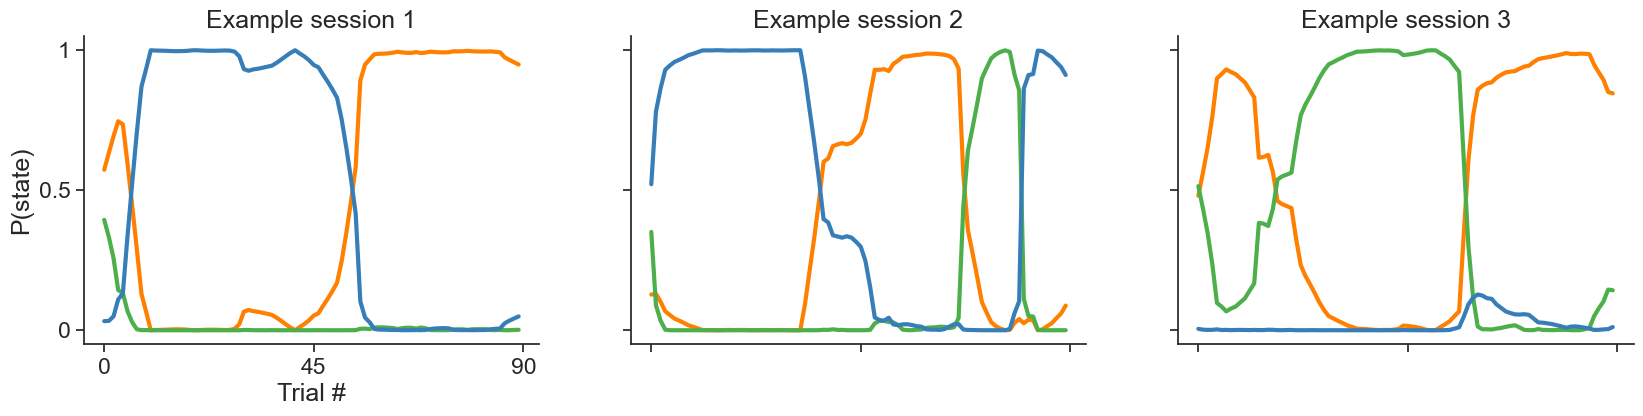

In [ ]:
sess_to_plot = ['0ccee376-2873-47dd-9293-c19e424c1bee','66f20f92-171f-4cc5-aca9-69fc3cb6370f',
                '19f4acbd-aeac-4f83-9f30-85a8aa002820']

sess_ex_1 = np.where(session == sess_to_plot[0])
sess_ex_2 = np.where(session == sess_to_plot[1])
sess_ex_3 = np.where(session == sess_to_plot[2])

sess_examples = [sess_ex_1, sess_ex_2, sess_ex_3]
posteriors = model.smooth_proba(design_matrix, choices_tsd)

colors =["#ff7f00", "#4daf4a", "#377eb8"]
fig, ax = plt.subplots(1,3,figsize=(20, 4))
for example_session in range(len(ax)):
    for state in range(3):
        ax[example_session].plot(posteriors[sess_examples[example_session][0][0]:sess_examples[example_session][0][0]+90][:, state],
                    label="State " + str(state + 1), lw=3,
                    color=colors[state])
        ax[example_session].set_title("Example session " + str(example_session + 1))#, fontsize=10)
        if example_session == 0:
            ax[example_session].set_xticks(
                [
                    sess_examples[example_session][0][0], 
                    sess_examples[example_session][0][0] + 45, 
                    sess_examples[example_session][0][0] + 90
                ], 
                [
                    "0", 
                    "45", 
                    "90"
                ], 
            )
            ax[example_session].set_ylabel("P(state)")
            ax[example_session].set_xlabel("Trial #")
            ax[example_session].set_yticks(
                [0, 0.5, 1], 
                ["0", "0.5", "1"], 
            )
        else:
            ax[example_session].set_xticks(
                [
                    sess_examples[example_session][0][0], 
                    sess_examples[example_session][0][0] + 45, 
                    sess_examples[example_session][0][0] + 90
                ], 
                [
                    " ", 
                    " ", 
                    " "
                ], 
            )
            ax[example_session].set_yticks(
                [0, 0.5, 1], 
                [" ", " ", " "], 
            )

### 04.5 Using ```decode_state``` to compute fraction of occupancy and accuracy per state
Ashwood: Overall accuracy of this mouse (gray) and accuracy for each of the three states. g, Psychometric curve for each state, conditioned on previous reward and previous choice.

Although this mouse had an overall accuracy of 80%, it achieved 90% accuracy in the engaged state compared to only 60% and 58% accuracy in the two biased states (Fig. 2f).

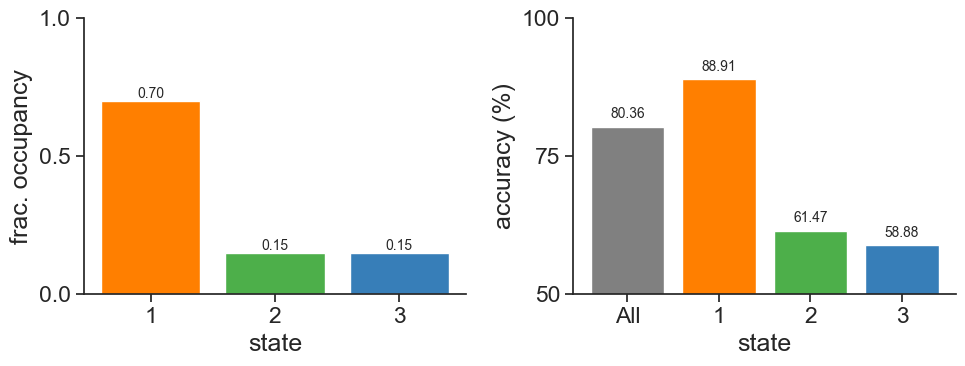

In [ ]:
cols = [
      "#ff7f00", "#4daf4a", "#377eb8", '#f781bf', '#a65628', '#984ea3',
        '#999999', '#e41a1c', '#dede00'
    ]

state_occupancies = []
for state in range(n_states):
    # Using viterbi
    #idx_of_interest = np.where(model.decode_state(design_matrix,choices_mouse, state_format = "index")==state)[0] 
    
    # Ashwood way
    posterior_probs = model.smooth_proba(design_matrix, choices_mouse)
    states_max_posterior = np.argmax(posterior_probs, axis=1)
    idx_of_interest = np.where(states_max_posterior == state)[0]
    occ = len(idx_of_interest)/len(choices_mouse)
    state_occupancies.append(occ)

#unnormalized_inpt, _, _ = load_data("IBL/CSHL_008" +
#                                        '_unnormalized.npz')
accuracies_to_plot = []
not_zero_loc = np.where(unnormalized_inpt[:, 0] != 0)[0] # unnormalized input 

correct_ans = (np.sign(unnormalized_inpt[not_zero_loc, 0]) + 1) / 2
acc = np.sum(choices_mouse[not_zero_loc] == correct_ans) / len(correct_ans)
accuracies_to_plot.append(acc) # Append total accuracy

for state in range(n_states): # Append accuracy per state
    # index of time points where the most likely state is 0
    #idx_of_interest = np.where(model.decode_state(X_mouse,choices_mouse, state_format = "index")==state) 
    # viterbi yields a slightly different result
    
    posterior_probs = model.smooth_proba(design_matrix, choices_mouse)
    idx_of_interest = np.where(posterior_probs[:, state] >= 0.9)[0]
    
    # viterbi to get label and filter posterior to pick the states
    # do both and explain differences?
    
    inpt_this_state, unnormalized_inpt_this_state, y_this_state = \
        design_matrix[idx_of_interest, :], unnormalized_inpt[idx_of_interest, :], \
        choices_mouse[idx_of_interest]

    not_zero_loc = np.where(unnormalized_inpt_this_state[:, 0] != 0)[0]
    
    correct_ans = (np.sign(unnormalized_inpt_this_state[not_zero_loc, 0]) + 1) / 2
    acc = np.sum(y_this_state[not_zero_loc] == correct_ans) / len(correct_ans)
    accuracies_to_plot.append(acc)  
    

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# --- Left: state occupancies ---
ax = axes[0]
for z, occ in enumerate(state_occupancies):
    ax.bar(z, occ, width=0.8, color=cols[z])
    ax.text(z, occ, f"{occ:.2f}", ha='center', va='bottom', fontsize=10)

ax.set_ylim(0, 1)
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['1', '2', '3'])
ax.set_yticks([0, 0.5, 1])
ax.set_xlabel('state')
ax.set_ylabel('frac. occupancy')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# --- Right: accuracies ---
ax = axes[1]
for z, acc in enumerate(accuracies_to_plot):
    col = 'grey' if z == 0 else cols[z - 1]
    ax.bar(z, acc * 100, width=0.8, color=col)
    ax.text(z, acc * 100 + 1, f"{acc*100:.2f}", ha='center', va='bottom', fontsize=10)

ax.set_ylim(50, 100)
ax.set_xticks([0, 1, 2, 3])
ax.set_xticklabels(['All', '1', '2', '3'])
ax.set_yticks([50, 75, 100])
ax.set_xlabel('state')
ax.set_ylabel('accuracy (%)')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()

should add fraction of occupancy and fraction of session with number of state changes

Ashwood: Moreover, the mouse changed state at least once within a session in roughly 71% of all 90-trial sessions and changed multiple times in 59% of sessions (Fig. 3e). This rules out the possibility that the states merely reflect the use of different strategies on different days. Rather, the mouse tended to remain in an engaged, high-performance state for tens of trials at a time, with lapses arising predominantly during interludes when it adopted a left-biased or right-biased strategy for multiple trials in a row. The multi-state GLM-HMM thus provides a very different portrait of mouse decision-making behavior than the basic GLM or lapse model.

## 05. Conclusions and next steps
conclusionary conclusion la conclusión que concluyo c'est fini

follow state descriptions in the paper
if you dont segment the paper then you would not be able to see some effects (see in what way they do that) -> explain at the very begining as a motivation and in the end as an interpretation -> why they thought to use this method

- show the class or link to the class name and show all code again. Creatte design matrix and fit the model. Emphasize. This is brief and its quick. 


## Additional resources
- ssm tutorial: https://github.com/zashwood/ssm/blob/master/notebooks/2b%20Input%20Driven%20Observations%20(GLM-HMM).ipynb

## References
<a id="ref1a"><a href="#cite1a">[1a]</a> Ashwood, Z. C., Roy, N. A., Stone, I. R., Laboratory, I. B., Urai, A. E., Churchland, A. K., Pouget, A., & Pillow, J. W. (2022). Mice alternate between discrete strategies during perceptual decision-making. Nature Neuroscience, 25(2), 201–212.

The International Brain Laboratory, Aguillon-Rodriguez, V., Angelaki, D., Bayer, H., Bonacchi, N., Carandini, M., Cazettes, F., Chapuis, G., Churchland, A. K., Dan, Y., Dewitt, E., Faulkner, M., Forrest, H., Haetzel, L., Häusser, M., Hofer, S. B., Hu, F., Khanal, A., Krasniak, C., … Zador, A. M. (2021). Standardized and reproducible measurement of decision-making in mice. eLife, 10, e63711. https://doi.org/10.7554/eLife.63711

Burgess, C. P., Lak, A., Steinmetz, N. A., Zatka-Haas, P., Bai Reddy, C., Jacobs, E. A. K., Linden, J. F., Paton, J. J., Ranson, A., Schröder, S., Soares, S., Wells, M. J., Wool, L. E., Harris, K. D., & Carandini, M. (2017). High-Yield Methods for Accurate Two-Alternative Visual Psychophysics in Head-Fixed Mice. Cell Reports, 20(10), 2513–2524. https://doi.org/10.1016/j.celrep.2017.08.047

Escola, S., Fontanini, A., Katz, D., & Paninski, L. (2011). Hidden Markov models for the stimulus-response relationships of multistate neural systems. Neural Computation, 23(5), 1071–1132. https://doi.org/10.1162/NECO_a_00118

Bengio, Y., & Frasconi, P. (1995). An input-output HMM architecture. In G. Tesauro, D. S. Touretzky, & T. K. Leen (Eds.), Advances in neural information processing systems (Vol. 7, pp. 427–434). MIT Press.

Bishop, C. M. (2006). Pattern recognition and machine learning. Springer.


model:
<a id="ref1"></a><a href="#cite1a">[1a]</a> <a href="#cite1b">[1b]</a> <a href="#cite1c">[1c]</a> <a href="#cite1d">[1d]</a> Pillow, J. W., Shlens, J., Paninski, L., Sher, A., Litke, A. M., Chichilnisky, E. J., & Simoncelli, E. P. (2008). Spatio-temporal correlations and visual signalling in a complete neuronal population. Nature, 454(7207), 995-999. https://doi.org/10.1038/nature07140